In [ ]:
# 1) Subir kaggle.json.
from google.colab import files
files.upload()  # selecciona kaggle.json

# 2) Instalar y configurar credenciales
!pip -q install kaggle #instalamos la librería oficial de Kaggle para Python
!mkdir -p /root/.kaggle #crea el directorio (si no existe).
!cp kaggle.json /root/.kaggle/kaggle.json #copia el archivo
!chmod 600 /root/.kaggle/kaggle.json #cambia los permisos para que solo yo (el usuario root) puedas leerlo — seguridad básica.

# 3) Descargar dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:19<00:00, 274MB/s]
100% 2.29G/2.29G [00:21<00:00, 115MB/s]


In [ ]:
import os, zipfile

# Buscar archivo descargado
zip_path = None
for f in os.listdir("/content"):
    if f.startswith("chest-xray-pneumonia") and f.endswith(".zip"):
        zip_path = os.path.join("/content", f)
        break

if zip_path is None:
    raise FileNotFoundError("No se encontró el dataset en /content. Asegúrate de que la descarga con kaggle se ejecutó bien.")

print("Usando archivo:", zip_path)

# Extraer
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

Usando archivo: /content/chest-xray-pneumonia.zip


In [ ]:

# === CELL 2: Subir kaggle.json ===
from google.colab import files
print("Por favor, sube tu archivo kaggle.json:")
uploaded = files.upload()

# Mover y dar permisos
for filename in uploaded.keys():
    !mv {filename} ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print(f"{filename} configurado correctamente")

# === CELL 3: Descargar dataset directamente en /content ===
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content

# === CELL 4: Descomprimir ===
import zipfile, os

zip_path = "/content/chest-xray-pneumonia.zip"
extract_path = "/content/chest-xray-pneumonia"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("¡Dataset descomprimido correctamente!")

# Mostrar estructura inicial
!find /content/chest-xray-pneumonia -type d | head -10

Por favor, sube tu archivo kaggle.json:


Saving kaggle.json to kaggle (1).json
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `mv kaggle (1).json ~/.kaggle/'
kaggle (1).json configurado correctamente
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
¡Dataset descomprimido correctamente!
/content/chest-xray-pneumonia
/content/chest-xray-pneumonia/chest_xray
/content/chest-xray-pneumonia/chest_xray/val
/content/chest-xray-pneumonia/chest_xray/val/PNEUMONIA
/content/chest-xray-pneumonia/chest_xray/val/NORMAL
/content/chest-xray-pneumonia/chest_xray/train
/content/chest-xray-pneumonia/chest_xray/train/PNEUMONIA
/content/chest-xray-pneumonia/chest_xray/train/NORMAL
/content/chest-xray-pneumonia/chest_xray/test
/content/chest-xray-pneumonia/chest_xray/test/PNEUMONIA


1. Exploración y análisis del dataset

Revisa la estructura de las carpetas, cantidad de imágenes disponibles por clase y formato de datos.

In [ ]:
# === PARTE 1: Auto-detección de carpeta base + conteos y formatos ===
import os #os permite navegar por las rutas de archivos y carpetas.
from collections import defaultdict, Counter #defaultdict y Counter ayudan a contar fácilmente cuántas imágenes hay por clase o por tipo de archivo.

def autodetect_base_dir():
    # Rutas comunes primero (rápido)
    comunes = [
        "/content/chest_xray",
        "/content/dataset/chest_xray",
        "/content/chest-xray-pneumonia/chest_xray",
    ]
    for p in comunes:
        if os.path.isdir(os.path.join(p, "train")) and os.path.isdir(os.path.join(p, "test")):
            return p

    # Búsqueda profunda (robusta)
    for root, dirs, files in os.walk("/content"):
        dirs_set = set(dirs)
        if {"train","test"}.issubset(dirs_set):
            # preferimos rutas que también tengan 'val', si existe
            if "val" in dirs_set:
                return root
            candidato = root  # por si no hay 'val'
    # Si llegamos aquí, puede que solo exista train/ y test/ en alguna ruta capturada
    return locals().get("candidato", None)

BASE_DIR = autodetect_base_dir()
print(" BASE_DIR detectada:", BASE_DIR)

if not BASE_DIR:
    print("\n No encontré una carpeta que contenga 'train' y 'test' debajo de /content.")
    print("Contenido de /content:", os.listdir("/content"))
else:
    # Ver estructura a un nivel
    print("\n Estructura inmediata dentro de BASE_DIR:", os.listdir(BASE_DIR))

    # Conteo de imágenes por split y clase + formatos por extensión
    EXTS_VALIDAS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    conteos = defaultdict(int)
    formatos = Counter()

    for split in ["train", "val", "test"]:
        split_dir = os.path.join(BASE_DIR, split)
        if not os.path.isdir(split_dir):
            continue
        for clase in sorted(d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))):
            clase_dir = os.path.join(split_dir, clase)
            for f in os.listdir(clase_dir):
                ext = os.path.splitext(f)[1].lower()
                if ext in EXTS_VALIDAS:
                    formatos[ext] += 1
                    conteos[(split, clase)] += 1

    # Mostrar resultados
    print("\n Conteo de imágenes por split y clase:\n")
    orden_splits = ["train","val","test"]
    clases_por_split = {}
    for split in orden_splits:
        clases = sorted({c for (s,c) in conteos.keys() if s == split})
        if not clases:
            continue
        clases_por_split[split] = clases
        for clase in clases:
            print(f"{split}/{clase}: {conteos[(split,clase)]} imágenes")

    print("\n Formatos de archivo encontrados (por extensión):")
    if formatos:
        for ext, n in formatos.items():
            print(f"{ext}: {n} archivos")
    else:
        print("No se detectaron imágenes con extensiones estándar en las subcarpetas.")

 BASE_DIR detectada: /content/dataset/chest_xray

 Estructura inmediata dentro de BASE_DIR: ['val', 'train', 'test', '__MACOSX', 'chest_xray']

 Conteo de imágenes por split y clase:

train/NORMAL: 1341 imágenes
train/PNEUMONIA: 3875 imágenes
val/NORMAL: 8 imágenes
val/PNEUMONIA: 8 imágenes
test/NORMAL: 234 imágenes
test/PNEUMONIA: 390 imágenes

 Formatos de archivo encontrados (por extensión):
.jpeg: 5856 archivos


La revisión inicial permite confirmar que el dataset está organizado correctamente en train, val y test, cada uno con las clases NORMAL y PNEUMONIA. También asegura que la cantidad de imágenes sea la esperada y que el formato sea homogéneo (.jpeg), lo cual facilita la carga y procesamiento de datos sin errores.

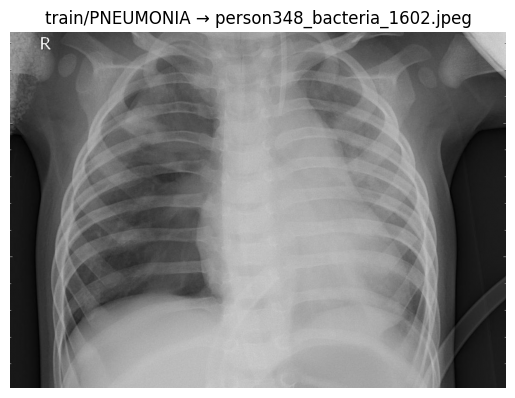

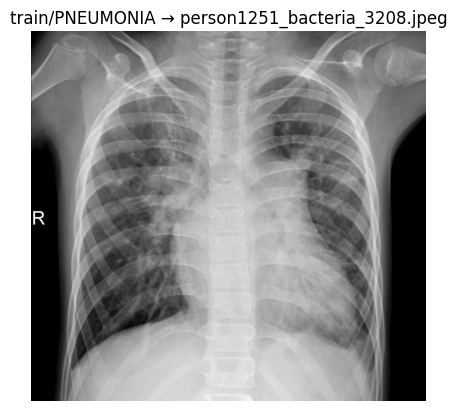

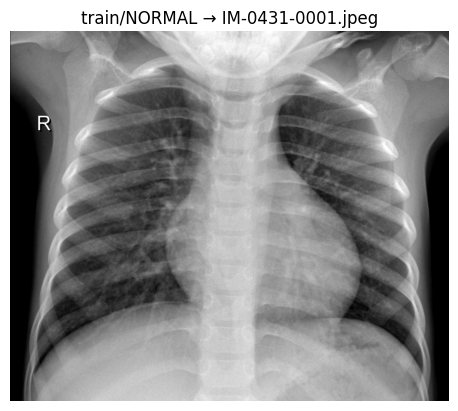

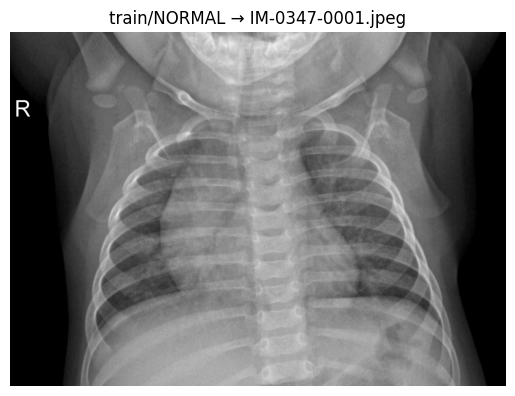

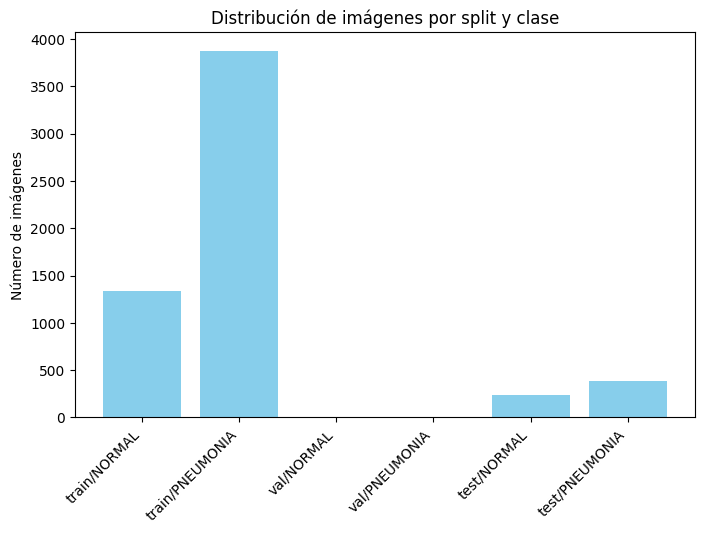

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image #abrir y manejar archivos de imagen.
import os

# --- Ejemplos de imágenes por clase ---
def mostrar_ejemplos(base_dir, split="train", muestras=2):
    clases = os.listdir(os.path.join(base_dir, split))
    for clase in clases:
        ruta_clase = os.path.join(base_dir, split, clase)
        imgs = [os.path.join(ruta_clase, f) for f in os.listdir(ruta_clase) if f.endswith(".jpeg")]
        seleccion = random.sample(imgs, muestras)
        for img in seleccion:
            plt.figure()
            plt.imshow(Image.open(img), cmap="gray")
            plt.title(f"{split}/{clase} → {os.path.basename(img)}")
            plt.axis("off")
    plt.show()

# Mostrar ejemplos del set de entrenamiento
mostrar_ejemplos(BASE_DIR, "train", muestras=2)


# --- Distribución de clases (gráfico) ---
import matplotlib.pyplot as plt

labels = [f"{s}/{c}" for (s,c) in conteos.keys()]
values = [conteos[(s,c)] for (s,c) in conteos.keys()]

plt.figure(figsize=(8,5))
plt.bar(labels, values, color="skyblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes por split y clase")
plt.show()

El análisis exploratorio brinda un panorama general del dataset: ejemplos de radiografías para verificar la calidad de los datos, la distribución de clases que revela un fuerte desbalance (PNEUMONIA >> NORMAL), y retos como la variación en resoluciones y el conjunto de validación reducido. Esta información es clave para planear técnicas de preprocesamiento y estrategias de balanceo que mejoren el rendimiento del modelo.

2. conceptos e implementacion de DataLoader
En PyTorch: Un DataLoader es un iterador optimizado que construye batches (simplemente un conjunto de muestras del dataset procesadas juntas en una sola pasada por el modelo.) de un Dataset. Gestiona de forma automática aspectos clave como:
shuffle: mezcla de datos en cada época, para romper correlaciones. num_workers: multiprocesamiento para cargar datos en paralelo. pin_memory: optimiza la transferencia de tensores entre memoria principal y GPU.sta collate_fn: define cómo agrupar varias muestras en un lote, útil cuando los datos tienen estructuras heterogéneas. Este objeto es esencial en cada época de entrenamiento porque garantiza que los datos se alimenten de manera eficiente al modelo.

En TensorFlow: El equivalente es el módulo tf.data.Dataset, que permite construir pipelines de entrada mediante transformaciones como shuffle, batch o prefetch. Estas operaciones se ejecutan de manera perezosa, paralela y asíncrona, especialmente cuando se usa num_parallel_calls=tf.data.AUTOTUNE. Así se optimiza el flujo de datos entre CPU y GPU.

funcionamiento: El DataLoader es el módulo encargado de preparar y suministrar los datos al modelo durante el entrenamiento y validación. Su rol va más allá de simplemente “leer archivos”; su función es garantizar que los datos lleguen en las condiciones correctas, de manera eficiente y reproducible.

Iterador de batches:

Divide el dataset en lotes (batches) y los entrega uno por uno al bucle de entrenamiento. Esto evita que el programador tenga que manejar manualmente los índices y cortes del dataset. Barajado de datos (shuffle):

Reorganiza las muestras en cada época para evitar que el modelo aprenda patrones no deseados por el orden de los datos. Paralelización de carga (num_workers):

Usa múltiples procesos para leer y transformar los datos en paralelo mientras la GPU está entrenando, reduciendo cuellos de botella de I/O. Preprocesamiento y transformaciones:

Integra transformaciones (escalado, normalización, aumentos de datos, etc.) para que los batches lleguen listos al modelo. Gestión de memoria (pin_memory):

Acelera la transferencia de tensores desde la RAM a la GPU fijando la memoria en un espacio óptimo. Muestreo personalizado:

Permite usar samplers (como WeightedRandomSampler) para tratar problemas de desbalance de clases. Flexibilidad de estructura (collate_fn):

Define cómo combinar muestras individuales en un batch, lo que es útil con datos que no son simples tensores homogéneos. Relación del batch_size con la optimización

Ruido del gradiente: Lotes pequeños generan gradientes más ruidosos, lo que puede favorecer la generalización pero requiere learning rates más conservadores.

Lotes grandes producen gradientes más estables, lo que permite tasas de aprendizaje mayores, pero demanda más memoria.

Memoria y tiempo: Lotes grandes ⇒ mayor consumo de RAM/VRAM pero mejor throughput.

Lotes pequeños ⇒ menor consumo de memoria pero entrenamiento más lento.

Estadística de batch: Con clases desbalanceadas, un batch pequeño puede sesgarse hacia la clase mayoritaria. Aquí es útil usar muestreo ponderado o pesos por clase en la función de pérdida.

el DataLoader y el batch_size

El DataLoader define el tamaño de lote El parámetro batch_size del DataLoader controla cuántas muestras entrega en cada iteración.

Ese lote es exactamente lo que el optimizador usa para calcular la pérdida y los gradientes en cada paso de actualización.

El DataLoader determina la “estadística” de los gradientes Si batch_size es pequeño, cada batch que entrega el DataLoader contendrá menos ejemplos, y por tanto el gradiente será más ruidoso.

Si batch_size es grande, cada batch se parecerá más al dataset completo, y el gradiente será más estable.

Barajado (shuffle) y representatividad El DataLoader puede mezclar los datos (shuffle=True), asegurando que cada batch tenga ejemplos variados.

Esto influye en la calidad de la estimación del gradiente: un buen shuffle evita que el optimizador vea lotes sesgados.

Muestreo especial (samplers) El DataLoader permite usar WeightedRandomSampler u otros métodos de muestreo.

Esto es clave en datasets desbalanceados: así, los batches que recibe el optimizador están equilibrados en clases, evitando que aprenda un gradiente sesgado.

Rendimiento y eficiencia del entrenamiento Gracias a opciones como num_workers y pin_memory, el DataLoader carga los batches en paralelo y los deja listos en la RAM o GPU.

Esto mantiene alimentado al optimizador sin “cuellos de botella” de datos, logrando que el cálculo de gradientes sea continuo y eficiente.

In [ ]:
!ls /content

 chest-xray-pneumonia	    dataset	       kaggle.json
 chest-xray-pneumonia.zip  'kaggle (1).json'   sample_data


In [ ]:
# Descomprimir dataset descargado
!unzip -q /content/chest-xray-pneumonia.zip -d /content/

# Verificar las carpetas creadas
!ls /content
!find /content -type d -maxdepth 2

 chest_xray		    dataset	       sample_data
 chest-xray-pneumonia	   'kaggle (1).json'
 chest-xray-pneumonia.zip   kaggle.json
find: warning: you have specified the global option -maxdepth after the argument -type, but global options are not positional, i.e., -maxdepth affects tests specified before it as well as those specified after it.  Please specify global options before other arguments.
/content
/content/.config
/content/.config/configurations
/content/.config/logs
/content/chest-xray-pneumonia
/content/chest-xray-pneumonia/chest_xray
/content/dataset
/content/dataset/chest_xray
/content/chest_xray
/content/chest_xray/val
/content/chest_xray/train
/content/chest_xray/test
/content/chest_xray/__MACOSX
/content/chest_xray/chest_xray
/content/sample_data


Clases: ['NORMAL', 'PNEUMONIA']
Nº imágenes TRAIN: 5216  |  TEST: 624
Vistos en una época (loader): {0: 2570, 1: 2646}
Ratio mayor/minor en LOTES: 1.03  (≈1.0 está balanceado)


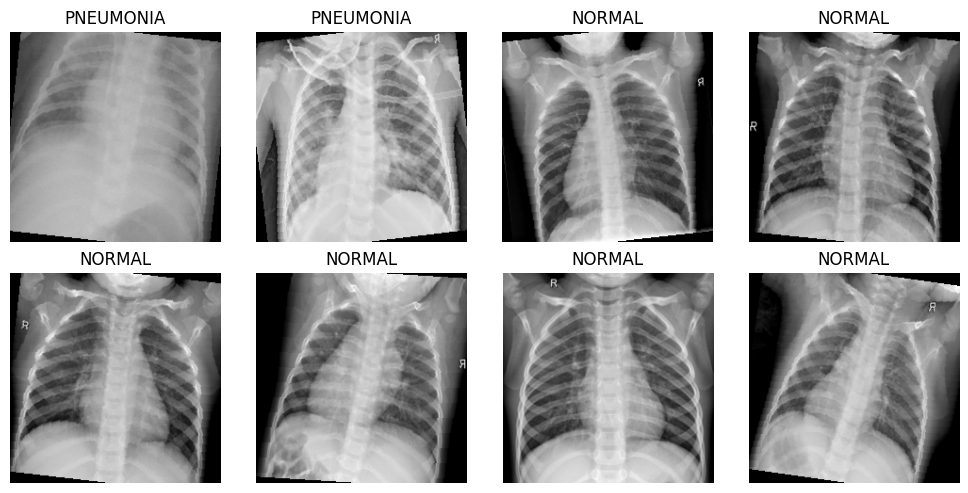

In [ ]:
# ---- PUNTO 2: DATA LOADER balanceado + verificación/visualización ----
#Vale corre hasta este por fa
import os, numpy as np, torch
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# === Rutas (usa tu BASE_DIR detectada o ajusta a mano) ===
train_dir = os.path.join(BASE_DIR, "train")
test_dir  = os.path.join(BASE_DIR, "test")

# === Transforms (puedes cambiar tamaño/augment si quieres) ===
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# === Cargar datasets ===
train_data = datasets.ImageFolder(root=train_dir, transform=transform_train)
test_data  = datasets.ImageFolder(root=test_dir,  transform=transform_test)

print(f"Clases: {train_data.classes}")  # ['NORMAL', 'PNEUMONIA']

# === Etiquetas de train (soporta distintas versiones de torchvision) ===
labels = np.array(train_data.targets if hasattr(train_data, "targets")
                  else [y for _, y in train_data.samples])

# === Pesos inversos por clase para balancear ===
# clase 0 -> NORMAL, clase 1 -> PNEUMONIA
class_counts  = np.bincount(labels)           # p.ej. [1341, 3875]
class_weights = 1.0 / class_counts            # inverso de la frecuencia
sample_weights = class_weights[labels]        # peso por muestra

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),          # una época recorre mismas muestras
    replacement=True
)

# === DataLoaders (con sampler NO uses shuffle) ===
batch_size = 16
train_loader = DataLoader(train_data, batch_size=batch_size, sampler=sampler,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"Nº imágenes TRAIN: {len(train_data)}  |  TEST: {len(test_data)}")

# -------- Verificación de balanceo (sin entrenar) --------
vistas = {0: 0, 1: 0}
for xb, yb in train_loader:   # 1 pasada por el loader (puede tardar un poco)
    for y in yb.tolist():
        vistas[int(y)] += 1
ratio_loader = max(vistas.values()) / max(1, min(vistas.values()))
print("Vistos en una época (loader):", vistas)
print(f"Ratio mayor/minor en LOTES: {ratio_loader:.2f}  (≈1.0 está balanceado)")

# -------- Visualización de un batch --------
images, labels_batch = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    img = images[i].permute(1, 2, 0)  # C,H,W -> H,W,C
    ax.imshow(img)
    ax.set_title(train_data.classes[labels_batch[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
!ls /content/dataset/chest_xray

chest_xray  __MACOSX  test  train  val


In [ ]:
import torch
print(torch.cuda.is_available())  # debe devolver True

True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

In [ ]:
# 1. Definir el modelo CNN
class PneumoniaCNN(nn.Module):
    def __init__(self):
        super(PneumoniaCNN, self).__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Clasificador
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


# 2. Configuración de entrenamiento
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Entrenando en: {device}")

model = PneumoniaCNN().to(device)

criterion = nn.BCELoss()  # porque la salida es Sigmoid (binaria)
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10  # puedes ajustar según recursos disponibles

# 3. Función de entrenamiento y validación
def train_model(model, criterion, optimizer, train_loader, test_loader, num_epochs):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = (outputs > 0.5).float()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc.item())

        # VALIDACIÓN
        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                preds = (outputs > 0.5).float()
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels)

        val_epoch_loss = val_loss / len(test_loader.dataset)
        val_epoch_acc = val_corrects.double() / len(test_loader.dataset)
        val_losses.append(val_epoch_loss)
        val_accs.append(val_epoch_acc.item())

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f}  Train Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_epoch_loss:.4f}  Val Acc: {val_epoch_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

Entrenando en: cuda


Epoch [1/10] Train Loss: 0.3675  Train Acc: 0.8453 | Val Loss: 1.2636  Val Acc: 0.5272
Epoch [2/10] Train Loss: 0.3102  Train Acc: 0.8827 | Val Loss: 1.2783  Val Acc: 0.6426
Epoch [3/10] Train Loss: 0.2925  Train Acc: 0.8859 | Val Loss: 0.5237  Val Acc: 0.7724
Epoch [4/10] Train Loss: 0.2608  Train Acc: 0.9026 | Val Loss: 1.4414  Val Acc: 0.6362
Epoch [5/10] Train Loss: 0.2551  Train Acc: 0.9028 | Val Loss: 17.0931  Val Acc: 0.6250
Epoch [6/10] Train Loss: 0.2552  Train Acc: 0.9018 | Val Loss: 0.5767  Val Acc: 0.7692
Epoch [7/10] Train Loss: 0.2399  Train Acc: 0.9112 | Val Loss: 6.1134  Val Acc: 0.6250
Epoch [8/10] Train Loss: 0.2286  Train Acc: 0.9178 | Val Loss: 1.7926  Val Acc: 0.6266
Epoch [9/10] Train Loss: 0.2255  Train Acc: 0.9170 | Val Loss: 0.6538  Val Acc: 0.7933
Epoch [10/10] Train Loss: 0.2135  Train Acc: 0.9178 | Val Loss: 2.1603  Val Acc: 0.6250
Tiempo total de entrenamiento: 17.44 min


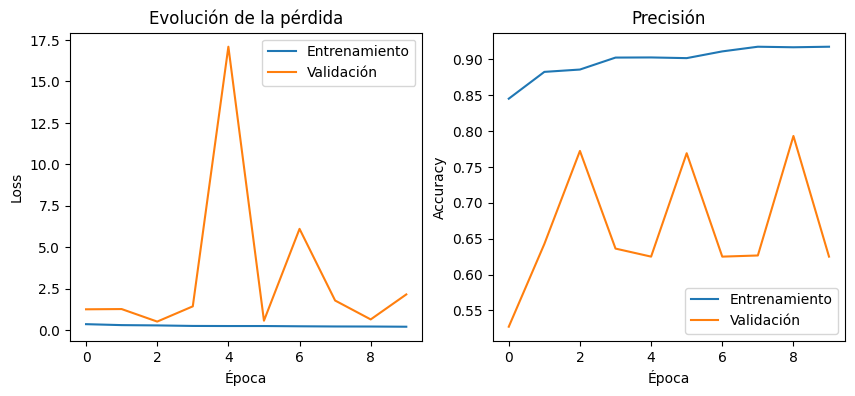

Modelo guardado como modelo_pneumonia.pth


In [ ]:
# 4. Entrenamiento del modelo
start_time = time.time()
train_losses, val_losses, train_accs, val_accs = train_model(model, criterion, optimizer, train_loader, test_loader, num_epochs)
print(f"Tiempo total de entrenamiento: {(time.time() - start_time)/60:.2f} min")

#5. Resultados
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Entrenamiento')
plt.plot(val_losses, label='Validación')
plt.title('Evolución de la pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Entrenamiento')
plt.plot(val_accs, label='Validación')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


# 6. Guardar el modelo entrenado
torch.save(model.state_dict(), "modelo_pneumonia.pth")
print("Modelo guardado como modelo_pneumonia.pth")

Percentiles de probas (0/25/50/75/95/100): [0.04171942 0.99795991 0.99986517 0.99998617 0.99999857 0.99999988]
Umbral elegido por F1: 0.99908

Accuracy: 0.8333 | ROC-AUC: 0.9075 | PR-AUC: 0.9435

NORMAL      Precision=0.822  Recall=0.709  F1=0.761  Soporte=234
PNEUMONIA   Precision=0.839  Recall=0.908  F1=0.872  Soporte=390

Reporte completo:
               precision    recall  f1-score   support

      NORMAL     0.8218    0.7094    0.7615       234
   PNEUMONIA     0.8389    0.9077    0.8719       390

    accuracy                         0.8333       624
   macro avg     0.8303    0.8085    0.8167       624
weighted avg     0.8325    0.8333    0.8305       624



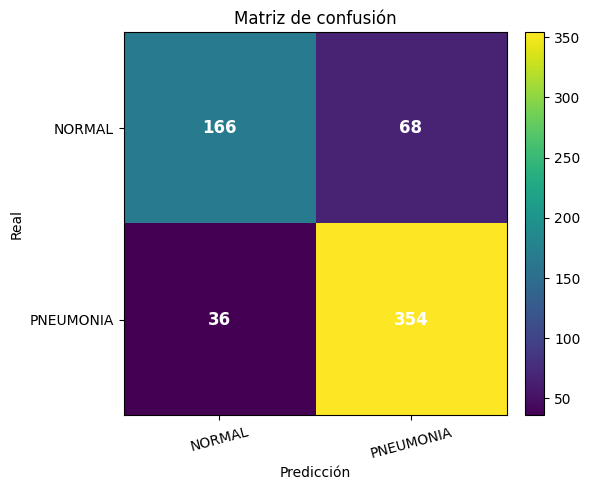

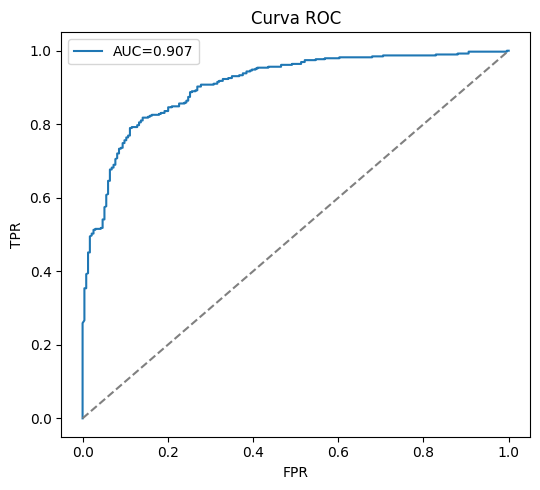

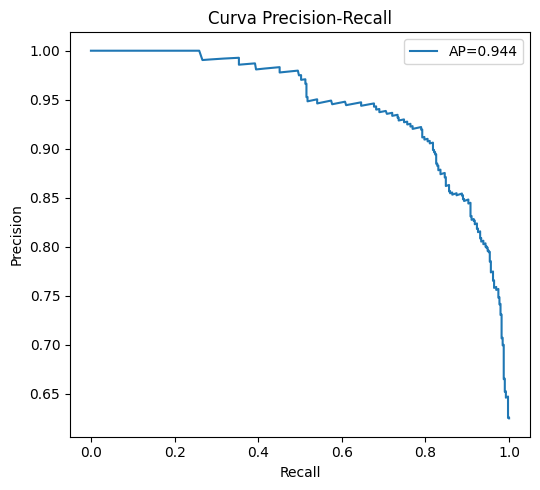

Mal clasificadas: 104


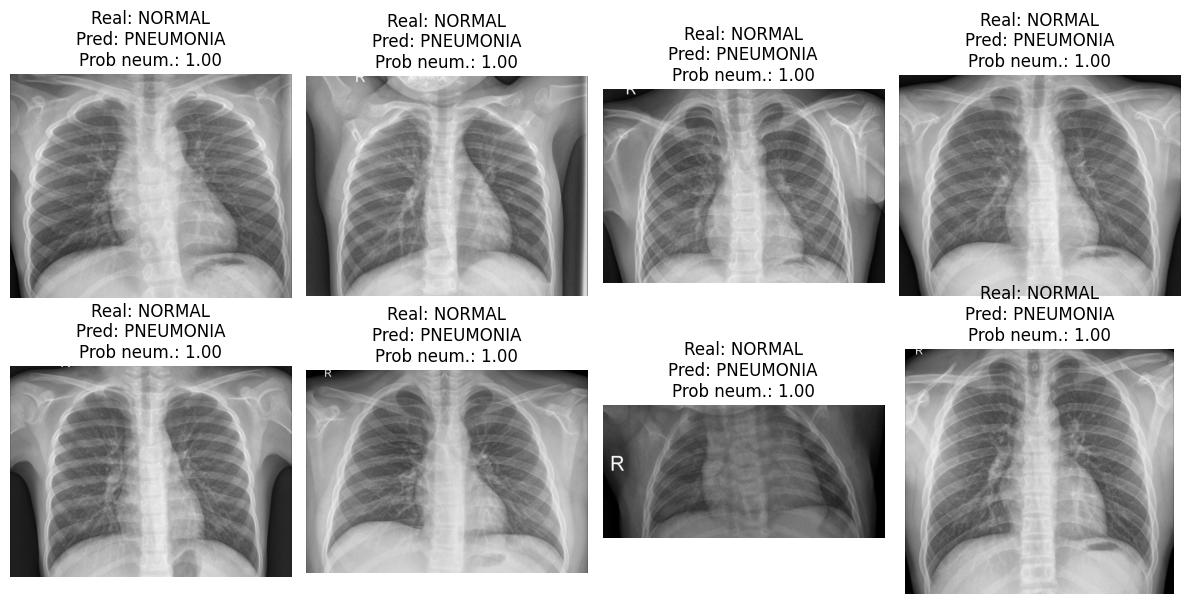

Archivos guardados en: /content/Resultados


In [ ]:
# ===== PUNTO 5: Evaluación en TEST (completo y robusto) =====
import os, json, numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    precision_recall_fscore_support, f1_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['NORMAL', 'PNEUMONIA']  # 0, 1

# --- 1) Recolectar probabilidades, etiquetas y rutas (sin aplicar Sigmoid extra) ---
APPLY_SIGMOID = not any(isinstance(m, nn.Sigmoid) for m in model.modules())  # tu modelo ya trae Sigmoid -> False
model.eval()
probs_list, y_true_list, paths_list = [], [], []

with torch.no_grad():
    seen = 0
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb).detach().cpu().squeeze(1)  # (N,1)->(N,)
        # Si tu modelo NO tuviera Sigmoid al final, la aplicaríamos aquí:
        if APPLY_SIGMOID:
            out = torch.sigmoid(out)
        probs_list.append(out.numpy())
        y_true_list.append(yb.numpy())
        # rutas de las imágenes (requiere test_loader con shuffle=False)
        batch_paths = [test_data.samples[i][0] for i in range(seen, seen+len(yb))]
        paths_list.extend(batch_paths)
        seen += len(yb)

y_true = np.concatenate(y_true_list).astype(int)
probs  = np.concatenate(probs_list).astype(float)

print("Percentiles de probas (0/25/50/75/95/100):",
      np.percentile(probs, [0,25,50,75,95,100]))

# --- 2) Elegir umbral por F1 de manera robusta ---
#   Barrer entre percentil 5 y 99.9 de tus probabilidades (evita rangos inútiles si todo está ~1)
p5, p999 = np.percentile(probs, 5), np.percentile(probs, 99.9)
if not np.isfinite(p5):   p5 = 0.3
if not np.isfinite(p999): p999 = 0.999
if p5 >= p999:            # por si todo viene casi idéntico
    p5, p999 = 0.90, 0.99995

umbral_grid = np.linspace(p5, p999, 300)
f1s = [f1_score(y_true, (probs >= t).astype(int)) for t in umbral_grid]
t_opt = float(umbral_grid[int(np.argmax(f1s))])

print(f"Umbral elegido por F1: {t_opt:.5f}")

# --- 3) Predicciones binarias y métricas globales ---
y_pred = (probs >= t_opt).astype(int)

acc = accuracy_score(y_true, y_pred)
prec, rec, f1, supp = precision_recall_fscore_support(
    y_true, y_pred, labels=[0,1], zero_division=0
)
roc_auc = roc_auc_score(y_true, probs)
ap_auc  = average_precision_score(y_true, probs)

print(f"\nAccuracy: {acc:.4f} | ROC-AUC: {roc_auc:.4f} | PR-AUC: {ap_auc:.4f}\n")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<10}  Precision={prec[i]:.3f}  Recall={rec[i]:.3f}  F1={f1[i]:.3f}  Soporte={supp[i]}")
print("\nReporte completo:\n",
      classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# --- 4) Matriz de confusión (anotada) ---
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
fig_cm, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap="viridis")
ax.set_title("Matriz de confusión")
ax.set_xlabel("Predicción"); ax.set_ylabel("Real")
ax.set_xticks([0,1]); ax.set_xticklabels(CLASS_NAMES, rotation=15)
ax.set_yticks([0,1]); ax.set_yticklabels(CLASS_NAMES)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

# --- 5) Curva ROC ---
fpr, tpr, _ = roc_curve(y_true, probs)
plt.figure(figsize=(5.5,5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Curva ROC")
plt.legend(); plt.tight_layout(); plt.show()

# --- 6) Curva Precision-Recall ---
prec_curve, rec_curve, _ = precision_recall_curve(y_true, probs)
plt.figure(figsize=(5.5,5))
plt.plot(rec_curve, prec_curve, label=f"AP={ap_auc:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Curva Precision-Recall")
plt.legend(); plt.tight_layout(); plt.show()

# --- 7) Ejemplos mal clasificados (hasta 8) ---
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Mal clasificadas: {len(wrong_idx)}")
if len(wrong_idx) > 0:
    import matplotlib.image as mpimg
    k = min(8, len(wrong_idx))
    fig_bad, axes = plt.subplots(2, 4, figsize=(12,6))
    for ax, idx in zip(axes.flat, wrong_idx[:k]):
        img = mpimg.imread(paths_list[idx])
        ax.imshow(img, cmap="gray")
        ax.set_title(f"Real: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}\nProb neum.: {probs[idx]:.2f}")
        ax.axis("off")
    plt.tight_layout(); plt.show()

# --- 8) Guardar resultados (PNG + TXT) ---
out_dir = Path("/content/Resultados"); out_dir.mkdir(parents=True, exist_ok=True)
with open(out_dir / "metricas.txt", "w") as f:
    f.write(f"Umbral_utilizado(F1): {t_opt:.5f}\n")
    f.write(f"Accuracy: {acc:.4f}\nROC-AUC: {roc_auc:.4f}\nPR-AUC: {ap_auc:.4f}\n\n")
    f.write(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
fig_cm.savefig(out_dir / "matriz_confusion.png", dpi=150)
print(f"Archivos guardados en: {out_dir}")